# 4 · ¿Por qué ningún modelo pasa de ~0.6? El techo estructural

**La observación:** IForest, AE, DAE, híbridos, VAE y ensembles — arquitecturas
muy distintas — quedan todas en una banda acotada, y el mejor no pasa de ~0.6. Cuando
familias tan diferentes chocan contra el mismo número, la sospecha cambia de lugar: ¿y
si el límite no está en los modelos sino en la **señal**?

**Tres análisis independientes** lo confirman.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 4.1 · Análisis cross-modelo: todos fallan en las MISMAS anomalías
`analyze_errors.py` alinea las predicciones de test de las **7 familias** (IForest, AE,
DAE, híbrido, VAE single, VAE seed-ensemble, DeepSVDD) y computa el consenso de errores
(detalle en `analysis/summary_soja.md`). Resultado (soja):

- **127 de 257 anomalías (49%) las fallan TODOS los modelos a la vez.**
- Las detectadas tienen precipitación claramente deficitaria (z medio **−0.84**); las
  falladas, clima cercano a lo normal (**−0.41**) — el **55% de las falladas no tiene
  firma climática** (precip_z ≥ −0.5).

Si cada modelo fallara en cosas distintas, un ensemble lo arreglaría; fallar todos en
las mismas apunta a la señal.

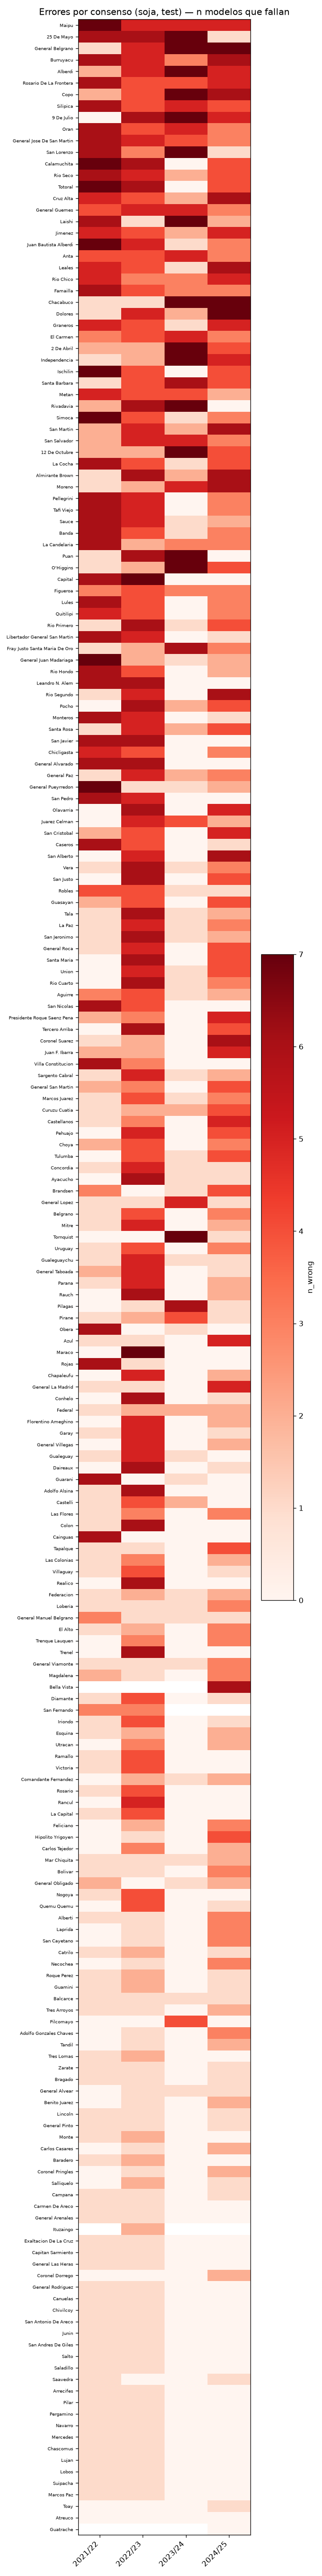

In [2]:
from IPython.display import Image, display
p = os.path.join(explib.ROOT, "analysis", "consensus_heatmap_soja.png")
display(Image(p)) if os.path.exists(p) else print("generar: python analyze_errors.py --cultivo soja")

El mismo fenómeno, medido dentro de cada run — el **recall estratificado** por causa
climática (anomalías con precipitación deficitaria vs el resto):

In [3]:
explib.show(explib.summary_fields([
    ("iforest_v2_mf03_n200","IForest"),
    ("vae_seedens_v1","VAE seed-ens")], "soja",
    keys=["recall_clima_adverso","n_clima_adverso","recall_otros","n_otros"]))

,modelo,recall_clima_adverso,n_clima_adverso,recall_otros,n_otros
0,IForest,0.3438,160,0.0000,97
1,VAE seed-ens,0.4750,160,0.0103,97


Las anomalías **con clima adverso** se detectan casi todas; las **"otras"** (rinde
anómalo con clima normal) casi ninguna — en todos los modelos.

## 4.2 · ¿Lo "consistentemente difícil" es anomalía? (Dataset Cartography)
Hipótesis propuesta por el docente: lo que el modelo reconstruye **siempre** mal podría
ser anomalía. La implementamos con dos herramientas: el **desacuerdo del ensemble**
(`score_std` entre los 10 miembros) y un **data map** (Swayamdipta 2020) adaptado a
reconstrucción: error por muestra **por época** → *confidence* + *variability* → mapa
easy / ambiguous / hard-to-learn.

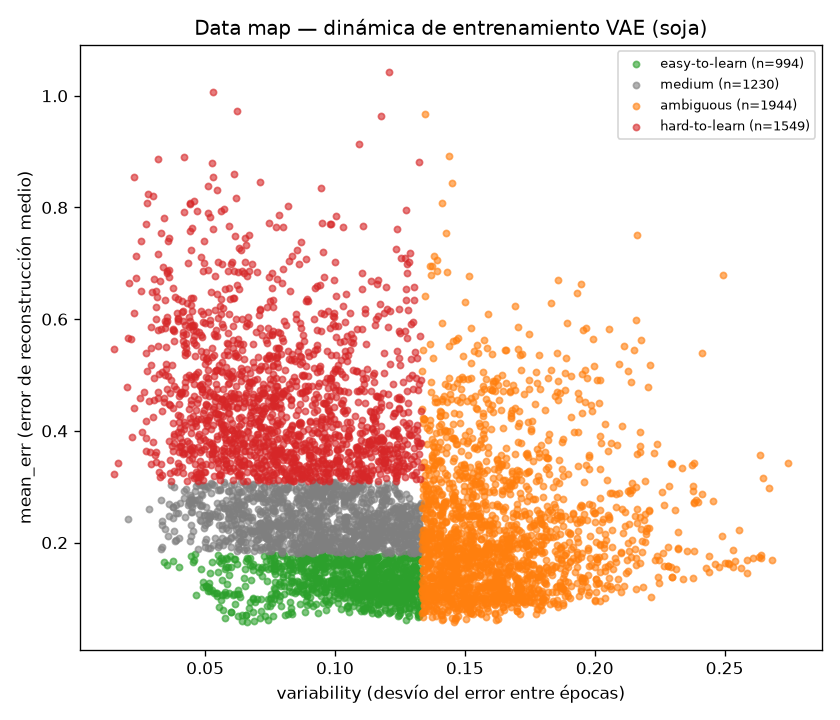

In [4]:
from IPython.display import Image, display
p = os.path.join(explib.ROOT, "analysis", "datamap_soja.png")
display(Image(p)) if os.path.exists(p) else print("generar: python analyze_datamap.py --cultivo soja")

**Resultado:** el **27% del train normal** es hard-to-learn, pero su `z_rinde`
medio (0.66) es igual al del train completo (0.69) → lo que cuesta reconstruir es
**rareza climática, no anomalía de rinde**. La hipótesis queda refutada como *detector* (y por
eso el modelo final no la usa para puntuar), pero validada como *auditoría*: confirma
que dificultad-de-reconstrucción ≠ anomalía-de-rinde, que es exactamente el techo.

## 4.3 · ¿Y si la etiqueta es ruido? (auditoría de `z_rinde`)
Última explicación posible: que las anomalías "invisibles" fueran artefactos de la
etiqueta proxy. `analyze_labels.py` clasifica cada anomalía por la fragilidad del
denominador del z-score (CV del baseline, z extremos, historia corta):

- La gran mayoría de las anomalías es **genuina** (86% en soja; 10% z-extremo, 4%
  baseline inestable).
- **Excluir las sospechosas EMPEORA la PR-AUC** (−0.021) → no son ruido removible.
- Las z-extremo (z < −5) se detectan a la misma tasa que las genuinas (recall 0.32 vs
  0.31) → son catástrofes reales, no artefactos.

**Refutado también:** el techo no es ruido de etiqueta.

## 4.4 · El techo, visto en el espacio de features (t-SNE)
Proyección t-SNE de las campañas de test coloreada por **etiqueta real** (izq.) y por
**score del VAE** (der.). Las anomalías (rojo) **no forman un cluster**: están mezcladas
entre las normales. Si no se distinguen en el espacio de features, ningún modelo que
mire ese espacio puede separarlas. El score del VAE (der.) marca una región — la de
**clima raro** — que solo se solapa parcialmente con el rojo.

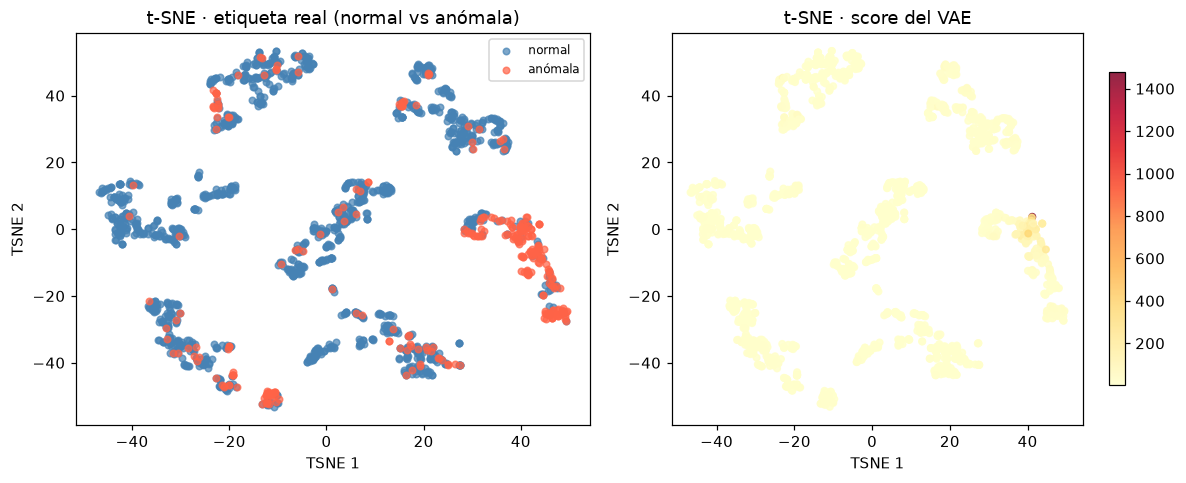

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
explib.plot_embeddings("vae_seedens_v1", "soja", method="tsne", color_by="label", ax=axs[0])
explib.plot_embeddings("vae_seedens_v1", "soja", method="tsne", color_by="score", ax=axs[1])
axs[0].set_title("t-SNE · etiqueta real (normal vs anómala)")
axs[1].set_title("t-SNE · score del VAE")
plt.tight_layout(); plt.show()

**Conclusión del notebook:** el techo es **estructural** — una mayoría de las
anomalías de rinde tiene causas no climáticas (plaga, granizo, manejo, mercado)
invisibles para un detector que solo ve clima. No es la arquitectura (todas fallan en
las mismas muestras) ni la etiqueta (la auditoría lo descarta). La única salida posible:
**darle al modelo más señal** — **próximo notebook**.